In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))  

import json

import torch

import matplotlib.pyplot as plt
from helpers.utils import set_seed
from helpers.viz import draw_yolo_boxes

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__, device)



2.12.0+cu130 cuda


In [2]:
from eytnet.config import Config
cfg = Config.load("configs/experiment.json")

print(json.dumps(cfg.raw, indent=2))
print("grid :", cfg.grid_sizes)
print("anchor:", cfg.anchors)

{
  "experiment_name": "eytnet_baseline",
  "data_root": "data",
  "class_names": [
    "fire",
    "smoke"
  ],
  "image_size": 640,
  "strides": [
    16,
    32
  ],
  "anchors_path": "configs/anchors.json",
  "seed": 42,
  "batch_size": 16,
  "num_workers": 4,
  "epochs": 30,
  "optimizer": "adam",
  "learning_rate": 0.001,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "lr_scheduler": "cosine",
  "final_lr_factor": 0.05,
  "warmup_epochs": 3,
  "augmentation_enabled": true,
  "use_clahe": false,
  "use_amp": true,
  "gradient_clip_norm": 10.0,
  "early_stopping_patience": 12,
  "lambda_box": 5.0,
  "lambda_objectness": 1.0,
  "lambda_class": 1.0,
  "negative_objectness_weight": 0.5,
  "ignore_iou_threshold": 0.5,
  "decode_score_floor": 0.01,
  "validation_score_threshold": 0.25,
  "nms_iou_threshold": 0.5,
  "max_detections": 300,
  "run_root": "models/eytnet"
}
grid : [40, 20]
anchor: [[(9.5, 11.0), (21.0, 22.5), (36.0, 48.0)], [(69.5, 80.0), (110.5, 148.5), (241.50000000000003,

In [3]:
from eytnet.dataset import FireDetectionDataset, build_dataloader
ds = FireDetectionDataset(cfg.data_root, "train", cfg.image_size, augment=True)

img, tgt, meta = ds[0]

print(len(ds), img.shape, img.dtype, img.min().item(), img.max().item())
print(tgt)

3900 torch.Size([3, 640, 640]) torch.float32 0.0 0.8235294222831726
tensor([[0.0000, 0.6211, 0.5987, 0.0636, 0.0531]])


In [4]:
from eytnet.model import build_model

model = build_model(cfg)
dummy = torch.randn(2,3,640,640)

outs = model(dummy)

for o, s in zip(outs, cfg.strides):
    print(s, tuple(o.shape))
print("parametre:", f"{model.count_parameters():,}")


16 (2, 3, 40, 40, 7)
32 (2, 3, 20, 20, 7)
parametre: 7,208,138


In [5]:
from eytnet.postprocess import anchors_to_tensors, decode_scale
anchors = anchors_to_tensors(cfg, "cpu")
d = decode_scale(outs[0], anchors[0], cfg.strides[0])
print(d.shape)                                            # (2, 3, 40, 40, 4)
print(d[..., 0].min().item(), d[..., 0].max().item())     # kabaca 0-640
print(d[..., 2].mean().item())                            # anchor genişlikleri mertebesinde


torch.Size([2, 3, 40, 40, 4])
5.723309516906738 633.5950927734375
21.43716049194336


In [6]:
from eytnet.dataset import build_dataloader

loader = build_dataloader(cfg, "train")
images, targets, metas = next(iter(loader))
print(images.shape, targets.shape, len(metas))
print(targets[:5])          # ilk sutun batch index, 0..15 arasi olmali

# outs'u AYNI batch'ten uret, dummy'den degil
outs = model(images)
print([tuple(o.shape) for o in outs])

torch.Size([16, 3, 640, 640]) torch.Size([18, 6]) 16
tensor([[0.0000, 0.0000, 0.7074, 0.6036, 0.0759, 0.0698],
        [1.0000, 0.0000, 0.6377, 0.6178, 0.0391, 0.0277],
        [2.0000, 0.0000, 0.3682, 0.5601, 0.0936, 0.0595],
        [3.0000, 0.0000, 0.2527, 0.6016, 0.0505, 0.0900],
        [4.0000, 0.0000, 0.9724, 0.5808, 0.0552, 0.1758]])
[(16, 3, 40, 40, 7), (16, 3, 20, 20, 7)]


In [ ]:
from eytnet.loss import EYTNetLoss, build_targets

assignments = build_targets(targets, cfg, "cpu")
for i, a in enumerate(assignments):
    print(f"scale {i} (stride {cfg.strides[i]}): {len(a['b'])} pozitif")

toplam = sum(len(a["b"]) for a in assignments)
print("toplam pozitif:", toplam, "| GT sayisi:", len(targets))
assert toplam == len(targets), "Her GT tam olarak bir hucreye atanmali!"

loss_fn = EYTNetLoss(cfg)
loss, parts = loss_fn(outs, targets)
print(round(float(loss), 4), parts)

loss0, parts0 = loss_fn(outs, torch.zeros((0, 6)))
print(float(loss0), parts0)      # patlamamali, box=0 cls=0 obj>0 olmali



scale 0: 12 pozitif
scale 1: 6 pozitif
toplam pozitif: 18 | GT sayisi: 18
6.2774 {'box': 0.9620270729064941, 'obj': 0.03965742513537407, 'cls': 1.427611231803894, 'positives': 18}
0.03574533760547638 {'box': 0.0, 'obj': 0.03574533760547638, 'cls': 0.0, 'positives': 0}


C:\Users\omert\AppData\Local\Temp\ipykernel_30896\1912606984.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  print(round(float(loss), 4), parts)


In [8]:
import numpy as np
from eytnet.metrics import evaluate_detections

CN = ["fire", "smoke"]

# 1) Mukemmel tahmin -> AP = P = R = 1
p = {"a": np.array([[10, 10, 50, 50, 0.9, 0]], np.float32)}
g = {"a": np.array([[10, 10, 50, 50, 0]], np.float32)}
r = evaluate_detections(p, g, CN)
print(r["per_class"]["fire"]["ap50"], r["per_class"]["fire"]["precision"])   # 1.0 1.0

# 2) Dar tahmin, IoU = 640/1600 = 0.4 < 0.5 -> FP
p2 = {"a": np.array([[10, 10, 26, 50, 0.9, 0]], np.float32)}
r2 = evaluate_detections(p2, g, CN)
print(r2["per_class"]["fire"]["tp"], r2["per_class"]["fire"]["fp"])          # 0 1

# 3) Ayni GT'ye iki tahmin -> ikincisi FP (cift sayim yok)
p3 = {"a": np.array([[10, 10, 50, 50, 0.9, 0],
                     [11, 11, 51, 51, 0.8, 0]], np.float32)}
r3 = evaluate_detections(p3, g, CN)
print(r3["per_class"]["fire"]["tp"], r3["per_class"]["fire"]["fp"])          # 1 1

# 4) Iki GT, ikinci tahmin ikinci GT'ye gitmeli
g4 = {"a": np.array([[10, 10, 50, 50, 0], [100, 100, 140, 140, 0]], np.float32)}
p4 = {"a": np.array([[10, 10, 50, 50, 0.9, 0], [12, 12, 52, 52, 0.8, 0],
                     [100, 100, 140, 140, 0.7, 0]], np.float32)}
r4 = evaluate_detections(p4, g4, CN)
print(r4["per_class"]["fire"]["tp"], r4["per_class"]["fire"]["fp"],
      r4["per_class"]["fire"]["fn"])                                        # 2 1 0


1.0 1.0
0 1
1 1
2 1 0


In [9]:
import copy

set_seed(0)
kucuk_model = build_model(cfg).to(device)
opt = torch.optim.Adam(kucuk_model.parameters(), lr=1e-3)
lf = EYTNetLoss(cfg)

x = images[:2].to(device)
t = targets[targets[:, 0] < 2].to(device)   # batch index 0 veya 1 olanlar

for i in range(150):
    lr = 1e-3 * min(1.0, (i + 1) / 50)          # WARMUP - bu satiri silme
    for g in opt.param_groups:
        g["lr"] = lr
    loss, parts = lf(kucuk_model(x), t)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(kucuk_model.parameters(), 10.0)
    opt.step()
    if i % 30 == 0 or i == 149:
        print(i, round(float(loss), 3), {k: round(v, 3) if isinstance(v, float) else v
                                         for k, v in parts.items()})


0 2.498 {'box': 0.36, 'obj': 0.037, 'cls': 0.658, 'positives': 2}
30 1.426 {'box': 0.257, 'obj': 0.019, 'cls': 0.124, 'positives': 2}
60 0.348 {'box': 0.06, 'obj': 0.006, 'cls': 0.043, 'positives': 2}
90 0.352 {'box': 0.064, 'obj': 0.004, 'cls': 0.026, 'positives': 2}
120 0.262 {'box': 0.046, 'obj': 0.003, 'cls': 0.027, 'positives': 2}
149 0.141 {'box': 0.023, 'obj': 0.003, 'cls': 0.022, 'positives': 2}


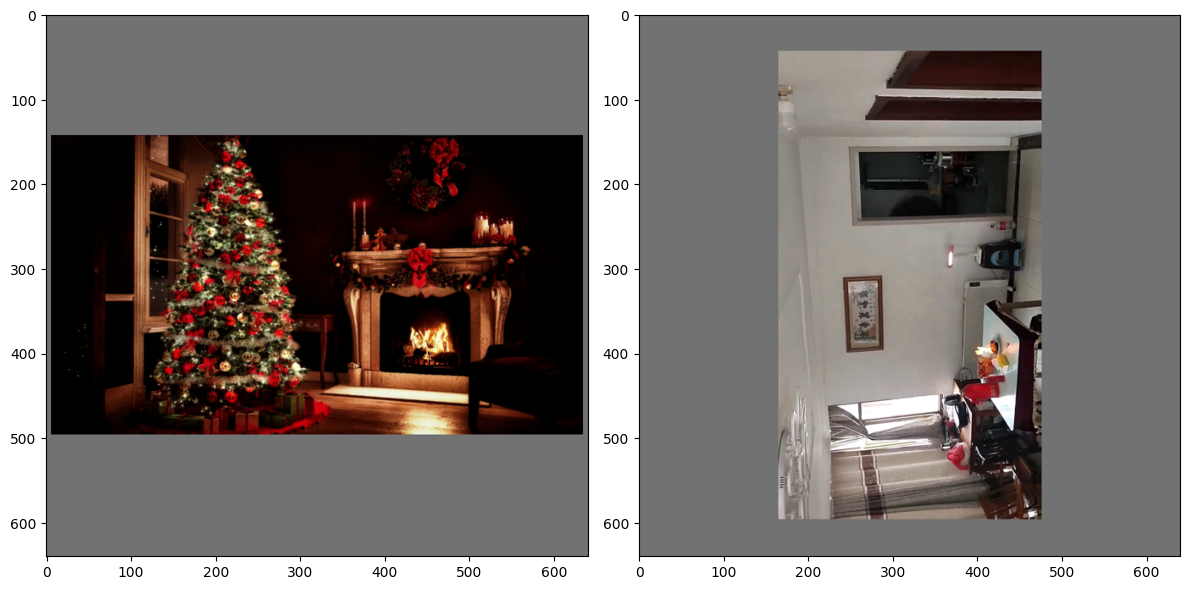

In [10]:
from eytnet.postprocess import postprocess

kucuk_model.eval()

with torch.no_grad():
    dets = postprocess(kucuk_model(x), cfg, score_threshold=0.23)

fig, axes = plt.subplots(1,2,figsize=(12,6))

for ax, im, d in zip(axes, x.cpu(), dets):
    ax.imshow(im.permute(1, 2, 0).numpy())
    for x1, y1, x2, y2, s, c in d.cpu().numpy():
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                                   edgecolor="red", linewidth=2))
        ax.text(x1, y1 - 3, f"{cfg.class_names[int(c)]} {s:.2f}",
                color="red", fontsize=8)
plt.tight_layout(); plt.show()